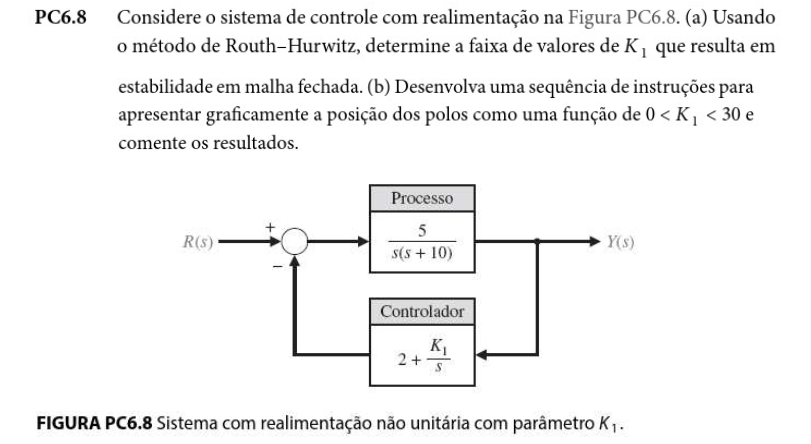

ITEM (a) - Critério de Routh-Hurwitz
------------------------------------
Polinômio característico:
s^3 + 10 s^2 + 10 s + 5 K1 = 0

Tabela de Routh:
s^3 | 1        10
s^2 | 10       5K1
s^1 | (100-5K1)/10   0
s^0 | 5K1

Para estabilidade, todos elementos da 1ª coluna > 0:
1 > 0
10 > 0
(100 - 5K1)/10 > 0
5K1 > 0

Logo:
K1 > 0
K1 < 20

Faixa estável:
0 < K1 < 20


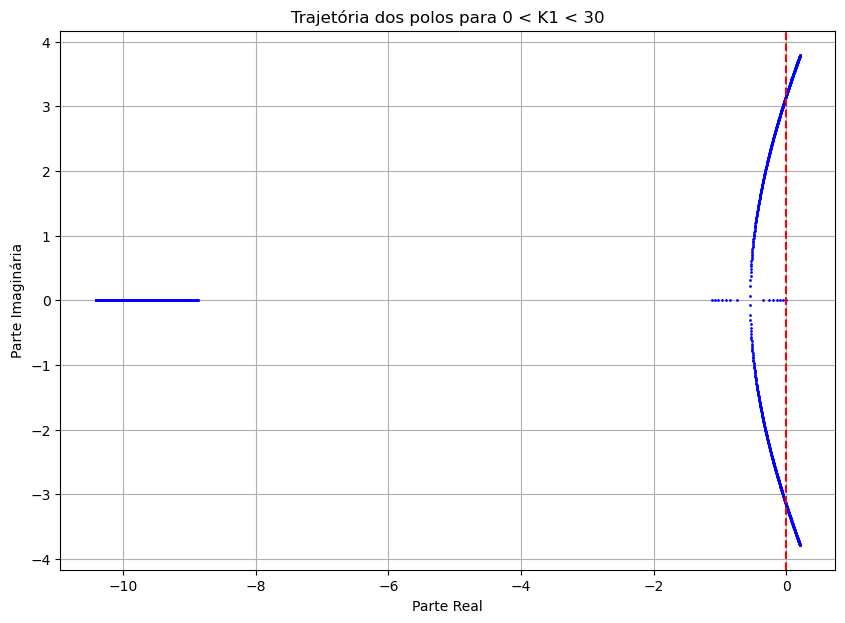


ITEM (b) - Comentários
----------------------
• Para 0 < K1 < 20: todos polos no semiplano esquerdo => sistema estável.
• Em K1 = 20: polos cruzam eixo imaginário => estabilidade marginal.
• Para K1 > 20: aparecem polos no semiplano direito => sistema instável.
• Ao aumentar K1, o sistema tende a ficar mais rápido inicialmente,
  porém perde estabilidade após K1 = 20.


In [1]:
# PC6.8 - Resolução em Python usando biblioteca control
# pip install control matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
import control as ctl

# ---------------------------------------------------
# Dados do sistema
# Processo:
# G(s) = 5 / [s(s+10)]
#
# Realimentação:
# H(s) = 2 + K1/s = (2s + K1)/s
#
# Equação característica:
# 1 + G(s)H(s) = 0
# s^3 + 10s^2 + 10s + 5K1 = 0
# ---------------------------------------------------

# ===================================================
# ITEM (a) - Routh-Hurwitz
# ===================================================

print("ITEM (a) - Critério de Routh-Hurwitz")
print("------------------------------------")
print("Polinômio característico:")
print("s^3 + 10 s^2 + 10 s + 5 K1 = 0\n")

print("Tabela de Routh:")
print("s^3 | 1        10")
print("s^2 | 10       5K1")
print("s^1 | (100-5K1)/10   0")
print("s^0 | 5K1\n")

print("Para estabilidade, todos elementos da 1ª coluna > 0:")
print("1 > 0")
print("10 > 0")
print("(100 - 5K1)/10 > 0")
print("5K1 > 0\n")

print("Logo:")
print("K1 > 0")
print("K1 < 20\n")

print("Faixa estável:")
print("0 < K1 < 20")


# ===================================================
# ITEM (b) - Polos para 0 < K1 < 30
# ===================================================

K_vals = np.linspace(0.01, 30, 400)

plt.figure(figsize=(10,7))

for K1 in K_vals:
    
    # Numerador e denominador de G(s)H(s)
    # G(s)H(s)= 5(2s+K1)/[s²(s+10)]
    
    num = [10, 5*K1]
    den = [1, 10, 0, 0]
    
    L = ctl.TransferFunction(num, den)
    
    # Malha fechada
    T = ctl.feedback(L, 1)
    
    polos = ctl.poles(T)
    
    plt.plot(np.real(polos), np.imag(polos), 'b.', markersize=2)

# eixo imaginário
plt.axvline(0, color='r', linestyle='--')

plt.title("Trajetória dos polos para 0 < K1 < 30")
plt.xlabel("Parte Real")
plt.ylabel("Parte Imaginária")
plt.grid(True)
plt.show()


# ===================================================
# Comentários automáticos
# ===================================================

print("\nITEM (b) - Comentários")
print("----------------------")
print("• Para 0 < K1 < 20: todos polos no semiplano esquerdo => sistema estável.")
print("• Em K1 = 20: polos cruzam eixo imaginário => estabilidade marginal.")
print("• Para K1 > 20: aparecem polos no semiplano direito => sistema instável.")
print("• Ao aumentar K1, o sistema tende a ficar mais rápido inicialmente,")
print("  porém perde estabilidade após K1 = 20.")